# Holographic vs Physical Axicon

Stage C route comparison. Holographic and physical axicons may target similar conical wavevectors, but they differ in blaze/order filtering, aperture, efficiency, aberrations, alignment, and hardware status.

In [1]:
from pathlib import Path

import pandas as pd

import bessel_twin_core as bt
from vbb_study import setup_study, vbb_train_viz
from vbb_study.publication import lab_realism as lab_schema

PATHS = setup_study.bootstrap(Path.cwd())
PRESET = "fast"
RUN_ID = PATHS.get("run_id") or None
base = bt.default_config(PRESET)
out_fig = PATHS["figures"] / "stage_c"
out_csv = PATHS["csv"] / "stage_c"
out_fig.mkdir(parents=True, exist_ok=True)
out_csv.mkdir(parents=True, exist_ok=True)


## Editable Notebook Controls

<!-- STAGE88: editable controls -->

This cell exposes the intended user-editable controls for exploratory runs. The locked stage logic below is preserved: changing these controls is for local investigation unless the notebook explicitly wires a value into a regenerated canonical output. Keep QA, caveats, and fail/marginal labels visible. For fast beam-to-sample exploration use the quicklook notebook; for publication-grade outputs use the locked stage runner.


In [2]:
# STAGE88: visible editable controls for exploratory notebook use.
# Edit NOTEBOOK_CONTROLS below and re-run this cell to apply parameter
# overrides to `base` before running any study cell below.
from dataclasses import replace
from vbb_study.publication import notebook_controls as nb_controls
from vbb_study.config import um as _um

NOTEBOOK_CONTROLS = nb_controls.make_notebook_controls(
    stage='lab_realism',
    # ── edit these to override the base configuration ───────────────────────
    ell=3,
    target_core_diameter_um=3.0,
    target_bessel_length_um=150.0,
    objective_NA=0.45,
    blaze_period_px=20,
)

# Wire control parameters into `base` so downstream cells use them.
_p = NOTEBOOK_CONTROLS.parameters or {}
if "ell" in _p:
    base = replace(base, target=replace(base.target, ell=int(_p["ell"])))
if "target_core_diameter_um" in _p:
    base = replace(base, target=replace(base.target, target_core_diameter_m=float(_p["target_core_diameter_um"]) * _um))
if "target_bessel_length_um" in _p:
    base = replace(base, target=replace(base.target, target_bessel_length_m=float(_p["target_bessel_length_um"]) * _um))
if "objective_NA" in _p:
    base = replace(base, objective=replace(base.objective, NA=float(_p["objective_NA"])))
if "blaze_period_px" in _p:
    base = replace(base, slm=replace(base.slm, blaze_period_px=int(_p["blaze_period_px"])))

try:
    display(nb_controls.describe_controls(NOTEBOOK_CONTROLS))
except NameError:
    print(nb_controls.describe_controls(NOTEBOOK_CONTROLS).to_string(index=False))


,control,value
0,stage,lab_realism
1,run_mode,balanced
2,save_outputs,False
3,use_canonical_outputs,True
4,allow_publication_export,False
5,notes,Edit for exploration; keep QA labels/caveats v...
6,ell,3
7,target_core_diameter_um,3.0
8,target_bessel_length_um,150.0
9,objective_NA,0.45


In [3]:
# Interactive quicklook — adjust sliders and click "Update plots".
# Runs a fast preview only; nothing is saved.
from vbb_study.publication import notebook_widgets as nbw

_panel = nbw.interactive_quicklook(base, method='holographic', preset='fast')
display(_panel)


In [4]:
raw = vbb_train_viz.method_comparison_table(base)
rows = []
for row in raw.to_dict("records"):
    method = str(row.get("method", "")).lower()
    label = str(row.get("variant", row.get("path", "lab"))).lower()
    lab_schema.annotate_lab_realism_row(
        row,
        generation_method="physical_axicon" if method == "physical" else "holographic_axicon",
        model_level="hardware_route",
        hardware_status="future_hardware_required" if method == "physical" else "current_lab_realizable",
        plane_label="surface_plane",
        coordinate_frame="surface_plane_air_um",
        run_id=RUN_ID,
        preset=PRESET,
        path=str(row.get("path", "realistic")),
    )
    rows.append(row)
comparison = lab_schema.ordered_lab_realism_frame(rows)
comparison.to_csv(out_csv / "holographic_physical_method_comparison.csv", index=False)
comparison


,run_id,generated_at_utc,source_schema_version,preset,path,generation_method,model_level,hardware_status,plane_label,coordinate_frame,...,method,bessel_zone_um,feature_diameter_um,peak_fluence_J_cm2,side_to_core_peak_ratio,throughput_or_efficiency,realised_k_r_m_inv,slm2_residual_before_rad,slm2_residual_after_rad,validity_valid
0,20260616T144133Z,2026-06-16T14:41:33.041952+00:00,1.0.0,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,surface_plane,surface_plane_air_um,...,holographic,38.015567,3.270841,4.718381,0.376263,0.732111,1.603333e+06,NaN,NaN,True
1,20260616T144133Z,2026-06-16T14:41:33.042034+00:00,1.0.0,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,surface_plane_air_um,...,physical,113.937100,4.775000,14.381208,0.539002,0.950288,1.603333e+06,1.813817,0.007127,True
2,20260616T144133Z,2026-06-16T14:41:33.042081+00:00,1.0.0,fast,realistic,holographic_axicon,hardware_route,current_lab_realizable,surface_plane,surface_plane_air_um,...,holographic,249.745519,4.776797,0.605325,1.000000,0.000164,2.405000e+06,NaN,NaN,True
3,20260616T144133Z,2026-06-16T14:41:33.042119+00:00,1.0.0,fast,ideal,physical_axicon,hardware_route,future_hardware_required,surface_plane,surface_plane_air_um,...,physical,103.829493,3.267105,14.810231,0.104739,0.849770,2.405000e+06,1.813146,0.007086,True


## Topological Charge Comparison: Holographic vs Physical Route

**Finding F-A3p:** The physical axicon route uses `slm2_conjugate_mode='full'`, which applies the SLM1 conjugate pattern (including the conjugate of the helical phase) at SLM2 before the physical axicon. This cancels the SLM1 vortex phase, so the beam entering the axicon carries **no helical phase** and exits with **winding ≈ 0** — not the design ℓ=3.

The holographic route places the helical phase on SLM1 and the axicon blaze on SLM2 (then first-order selects), preserving the winding at **ℓ≈3** after filtering.

| Route | Expected charge | Measured winding | Root cause |
|---|---|---|---|
| Holographic | ℓ=3 | ≈ 3.0 | Vortex phase on SLM1, axicon on SLM2, first-order selects |
| Physical (`full` mode) | ℓ=3 | ≈ 0.0 | SLM2 conjugate cancels SLM1 helical phase before axicon |

Charge labels are computed from the measured field phase winding (closed-loop accumulation around the design ring radius), not hardcoded. See `vbb_study/viz_fields.py::measured_charge_label`.

Holographic (general/lab): measured winding = 3.00 (design ℓ=3; ✓ charge preserved)
Physical    (general/lab): measured winding = 0.00 (design ℓ=3; charge stripped; SLM2 conjugate_mode='full' strips the helical phase)


WindowsPath('C:/PhD/Code/Publication_Study/outputs/figures/stage_c/stage_c_sampling_qa_limits.png')

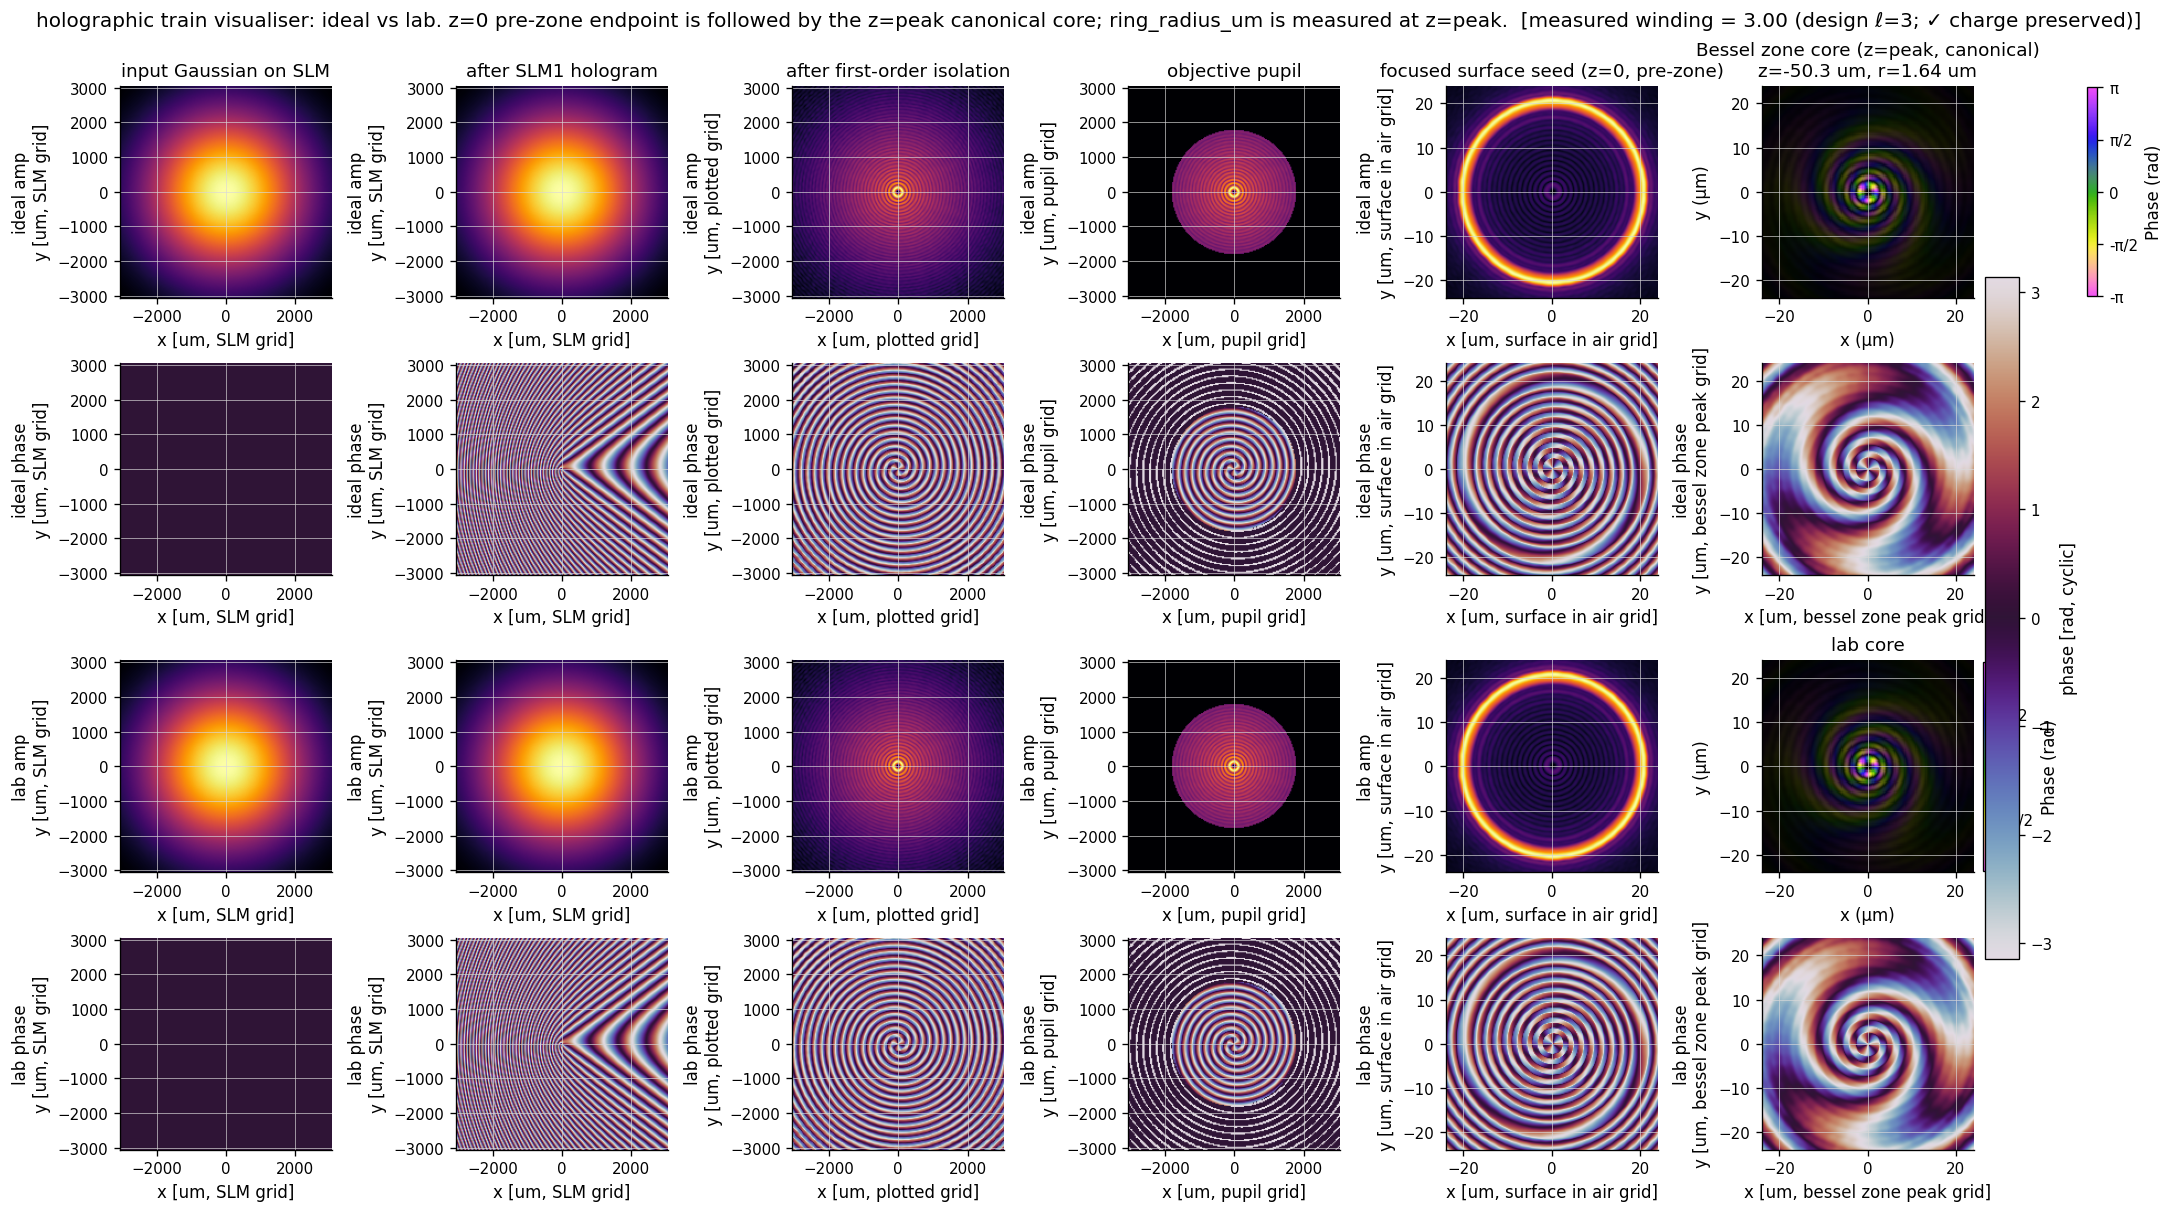

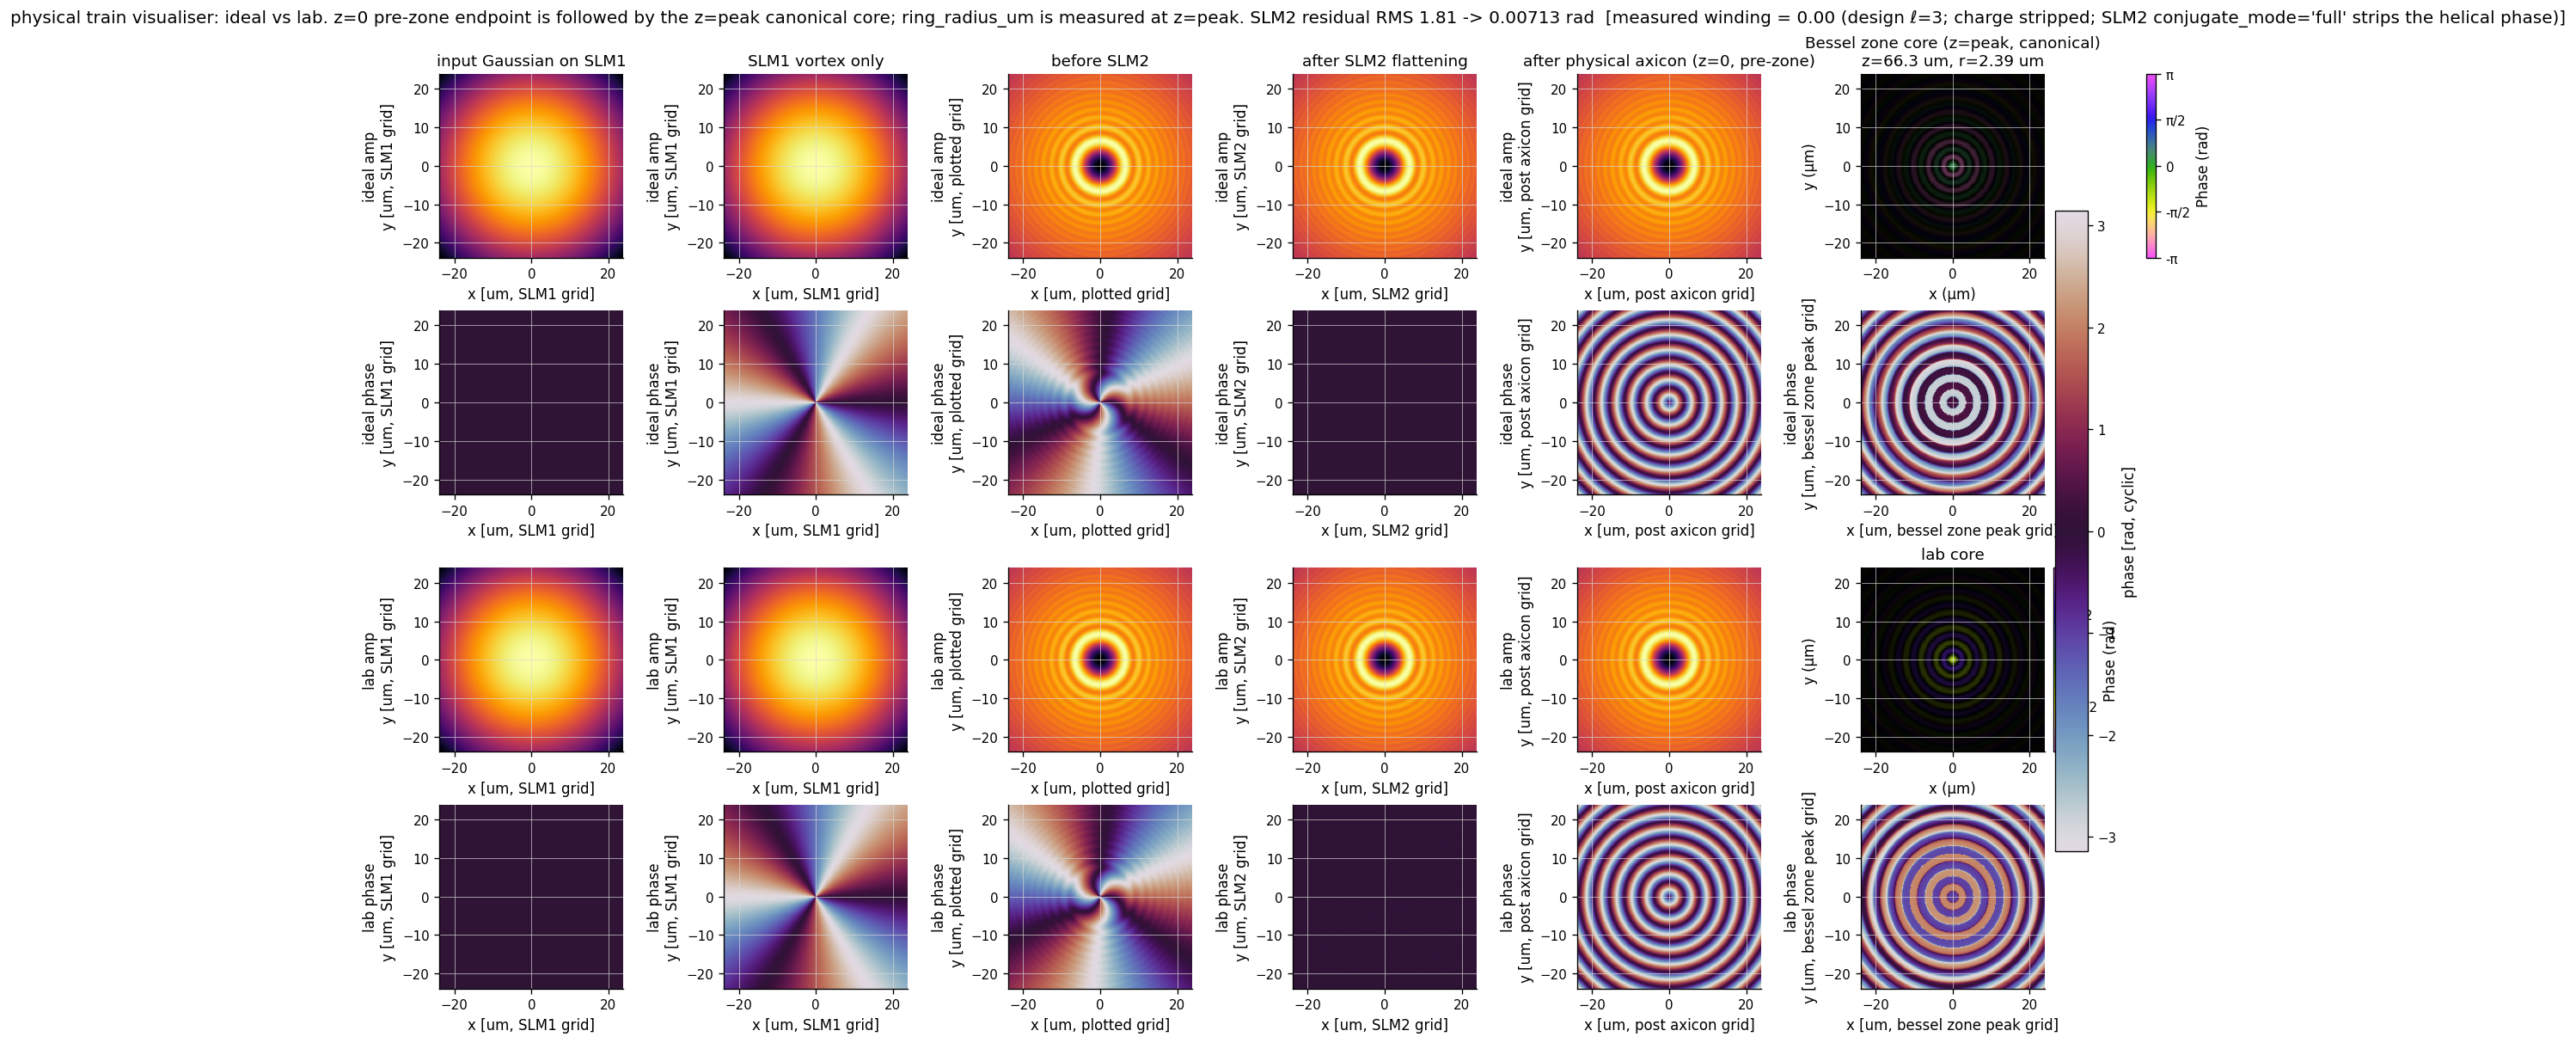

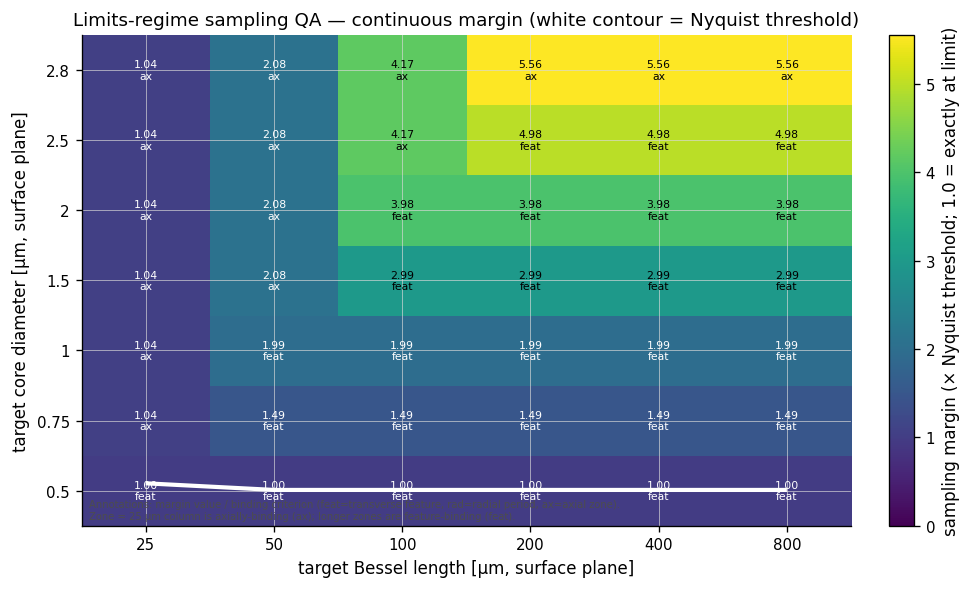

In [5]:
# Matched visual outputs generated by the shared Stage-C visualiser.
# Charge labels are MEASURED from the field (Finding F-A3p: physical full-mode winding ≈ 0).
from dataclasses import replace as _replace_nb03
from vbb_study import vbb_regime as _vbb_regime_nb03
from vbb_study.viz_fields import measured_charge_label as _mcl_nb03

# Quick fast run for holographic charge measurement (general, realistic path)
_holo_cfg = _vbb_regime_nb03.config_for_regime(
    _replace_nb03(base, generation_method="holographic"), "general"
)
_r_holo = bt.run_case(_holo_cfg, preset=PRESET, path="realistic", case_id="nb03_holo_charge")
_sf_h = _r_holo["surface_field"]
_des_h = _r_holo["design"]
_holo_lbl = _mcl_nb03(
    _sf_h.Ex, _sf_h.grid, float(_des_h.vortex_main_ring_radius_m),
    design_ell=int(_des_h.ell),
)

# Quick fast run for physical charge measurement (general, full conjugate mode)
_phys_cfg = _vbb_regime_nb03.config_for_regime(
    _replace_nb03(base, generation_method="physical"), "general"
)
_phys_cfg = _replace_nb03(_phys_cfg, physical_axicon=_replace_nb03(
    _phys_cfg.physical_axicon, slm2_stroke_levels=256, slm2_conjugate_mode="full"
))
_r_phys = bt.run_case(_phys_cfg, preset=PRESET, path="ideal", case_id="nb03_phys_charge")
_sf_p = _r_phys["surface_field"]
_des_p = _r_phys["design"]
_phys_lbl = _mcl_nb03(
    _sf_p.Ex, _sf_p.grid, float(_des_p.vortex_main_ring_radius_m),
    design_ell=int(_des_p.ell), conjugate_mode="full",
)

print(f"Holographic (general/lab): {_holo_lbl}")
print(f"Physical    (general/lab): {_phys_lbl}")

vbb_train_viz.plot_train_visualiser(base, method='holographic', output_dir=out_fig, charge_label=_holo_lbl)
vbb_train_viz.plot_train_visualiser(base, method='physical', output_dir=out_fig, charge_label=_phys_lbl)
vbb_train_viz.plot_sampling_qa(base, output_dir=out_fig)